In [ ]:
!pip install torchdiffeq

  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl (176.2 MB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (99 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21

In [ ]:
import matplotlib.pyplot as plt
import os
import argparse
import time
import numpy as np
import IPython
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from torchdiffeq import odeint
from scipy.interpolate import BSpline

In [ ]:
import sys
if "google.colab" in sys.modules:
    !wget "https://raw.githubusercontent.com/ndcbe/CBE60499/main/notebooks/helper.py"
    import helper
    helper.install_idaes()
    helper.install_ipopt()
    !pyomo build-extensions

--2024-05-21 19:15:35--  https://raw.githubusercontent.com/ndcbe/CBE60499/main/notebooks/helper.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7171 (7.0K) [text/plain]
Saving to: ‘helper.py’

helper.py           100%[===================>]   7.00K  --.-KB/s    in 0s      

2024-05-21 19:15:35 (56.1 MB/s) - ‘helper.py’ saved [7171/7171]

Installing idaes via pip...
idaes was successfully installed
Running idaes get-extensions to install Ipopt, k_aug, and more...
Ipopt 3.13.2 (x86_64-pc-linux-gnu), ASL(20190605)

[K_AUG] 0.1.0, Part of the IDAES PSE framework
Please visit https://idaes.org/ (x86_64-pc-linux-gnu), ASL(20190605)

Couenne 0.5.8 -- an Open-Source solver for Mixed Integer Nonlinear Optimization
Mailing list: couenne@list.coin-or.org
Instructions

In [ ]:
import tensorflow.keras as k
from pyomo.environ import *
from pyomo.dae import *


In [ ]:
!pip install git+https://github.com/cog-imperial/OMLT.git

  Cloning https://github.com/cog-imperial/OMLT.git to /tmp/pip-req-build-77sjwvtx
  Running command git clone --filter=blob:none --quiet https://github.com/cog-imperial/OMLT.git /tmp/pip-req-build-77sjwvtx
  Resolved https://github.com/cog-imperial/OMLT.git to commit e60563859a66ac5dd3348bf1763de57eec95171e
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 28.8 MB/s eta 0:00:00
  Created wheel for omlt: filename=omlt-1.1.post1.dev121+ge605638-py2.py3-none-any.whl size=54368 sha256=fcd883654b36643c9a9c3731e42ceb42af799f7347f30c70965a452b3b17720d
  Stored in directory: /tmp/pip-ephem-wheel-cache-n3nhxrku/wheels/53/93/d9/b409664fba5342c98ad450fa3d16c577f8a9996068e8c513d0
Successfully built omlt
  Attempting uninstall: pyomo
    Found existing installation: Pyomo 6.7.2
    Uninstalling Pyomo-6.7.2:
      Successfully uninstalled Pyomo-6.7.2
ERROR: 

In [ ]:
from omlt import OmltBlock, OffsetScaling
from omlt.neuralnet import FullSpaceNNFormulation, NetworkDefinition,ReluBigMFormulation,ReluComplementarityFormulation,ReducedSpaceNNFormulation
from omlt.io import load_keras_sequential

The class '_BlockData' has been renamed to 'BlockData'.  (deprecated
in 6.7.2)
(called from /usr/local/lib/python3.10/dist-packages/omlt/block.py:33)


Pyomo DAE Solve CS1

In [ ]:
m = ConcreteModel()

m.t = ContinuousSet(bounds=(0, 1))

m.x1 = Var(m.t, bounds=(0, 1))
m.x2 = Var(m.t, bounds=(0, 1))
m.u = Var(m.t, initialize=0)

m.x1dot = DerivativeVar(m.x1)
m.x2dot = DerivativeVar(m.x2)

m.obj = Objective(expr=m.x2[1])


def _x1dot(M, i):
    if i == 0:
        return Constraint.Skip
    return M.x1dot[i] == M.u[i]


m.x1dotcon = Constraint(m.t, rule=_x1dot)


def _x2dot(M, i):
    if i == 0:
        return Constraint.Skip
    return M.x2dot[i] == M.x1[i] ** 2 + M.u[i] ** 2


m.x2dotcon = Constraint(m.t, rule=_x2dot)


def _init(M):
    yield M.x1[0] == 1
    yield M.x2[0] == 0
    yield ConstraintList.End


m.init_conditions = ConstraintList(rule=_init)

In [ ]:
discretizer = TransformationFactory('dae.collocation')
discretizer.apply_to(m, nfe=10, ncp=2, scheme='LAGRANGE-RADAU')
i=0
for t in m.t:
  m.u[t].fix(OM_u[i])
  i=i+1

NameError: name 'OM_u' is not defined

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

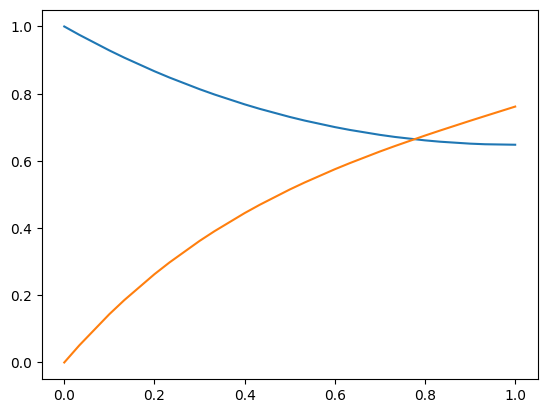

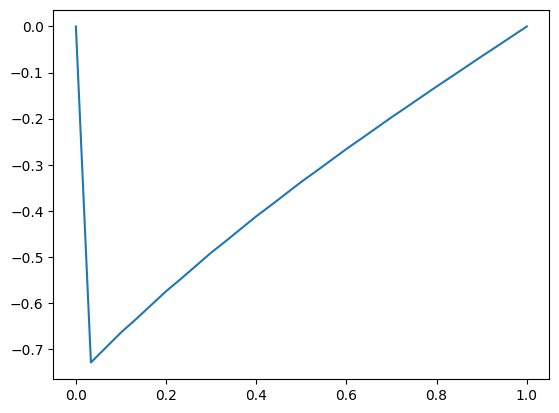

In [ ]:
discretizer = TransformationFactory('dae.collocation')
discretizer.apply_to(m, nfe=10, ncp=2, scheme='LAGRANGE-RADAU')
#discretizer.reduce_collocation_points(m, var=m.u, ncp=1, contset=m.t)

solver = SolverFactory('ipopt')

results = solver.solve(m, tee=True)

x1 = []
x2 = []
u = []
tt = []

print(sorted(m.t))

for i in sorted(m.t):
    tt.append(i)
    x1.append(value(m.x1[i]))
    x2.append(value(m.x2[i]))
    u.append(value(m.u[i]))

plt.plot(tt, x1)
plt.plot(tt, x2)
plt.show()

plt.plot(tt, u)
plt.show()

Pyomo DAE + OMLT Solve of System

In [ ]:
def _con_out1(m,t):
  if t==0:
    return Constraint.Skip
  return OM.dx1dt[t] == OM.nn[t].m.outputs[0]  #dx1dt


def _con_out2(m,t):
  if t==0:
    return Constraint.Skip
  return OM.dx2dt[t] == OM.nn[t].m.outputs[1]  #dx2dt


def _con_in1(m,t):
  #if t==0:
   # return Constraint.Skip
  return OM.x1[t] == OM.nn[t].m.inputs[1]  #x1


def _con_in2(m,t):
  #if t==0:
   # return Constraint.Skip
  return OM.x2[t] == OM.nn[t].m.inputs[2]  #x2


def _con_in3(m,t):
  #if t==0:
   # return Constraint.Skip
  return OM.u[t] == OM.nn[t].m.inputs[0]  #u

In [ ]:
OM=ConcreteModel()

#OM.nn=OmltBlock()

#OM.tf=Param(initialize=1)
OM.t =ContinuousSet(bounds=(0,1))

OM.u=Var(OM.t,initialize=0,bounds=(-3,1))
OM.x1=Var(OM.t,bounds=(0, 1))
OM.x2=Var(OM.t,bounds=(0, 1))


OM.dx1dt = DerivativeVar(OM.x1,wrt=OM.t)
OM.dx2dt = DerivativeVar(OM.x2,wrt=OM.t)

OM.obj = Objective(expr=OM.x2[1])

discretizer = TransformationFactory('dae.collocation')
discretizer.apply_to(OM, nfe=10, ncp=2, scheme='LAGRANGE-RADAU')

net=load_keras_sequential(model_tf)
formulation = FullSpaceNNFormulation(net)
formulation=ReluComplementarityFormulation(net)
OM.nn=Block(OM.t)
for t in OM.t:
  OM.nn[t].m=OmltBlock()
  OM.nn[t].m.build_formulation(formulation)

OM.nn[t].m.out1=Constraint(OM.t, rule=_con_out1)
OM.nn[t].out2=Constraint(OM.t, rule=_con_out2)
OM.nn[t].in1=Constraint(OM.t, rule=_con_in1)
OM.nn[t].in2=Constraint(OM.t, rule=_con_in2)
OM.nn[t].in3=Constraint(OM.t, rule=_con_in3)

In [ ]:
def _init(m):
  yield m.x1[0]==1
  yield m.x2[0]==0
  yield ConstraintList.End

OM.init_conditions=ConstraintList(rule=_init)

OM.u[0].fix(0.0)

In [ ]:
#discretizer.reduce_collocation_points(m, var=m.u, ncp=1, contset=m.t)

solver = SolverFactory('ipopt')

results = solver.solve(OM, tee=True)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

[0, 0.033333, 0.1, 0.133333, 0.2, 0.233333, 0.3, 0.333333, 0.4, 0.433333, 0.5, 0.533333, 0.6, 0.633333, 0.7, 0.733333, 0.8, 0.833333, 0.9, 0.933333, 1]


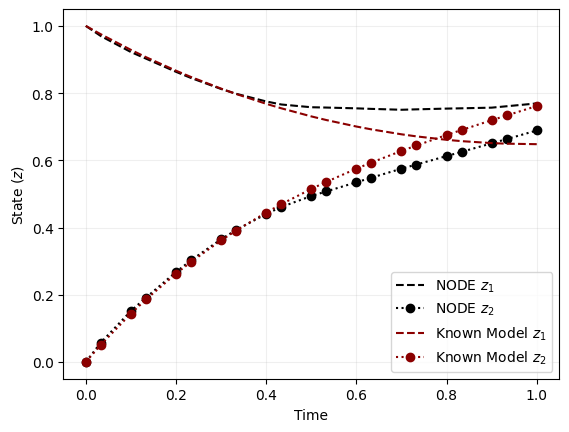

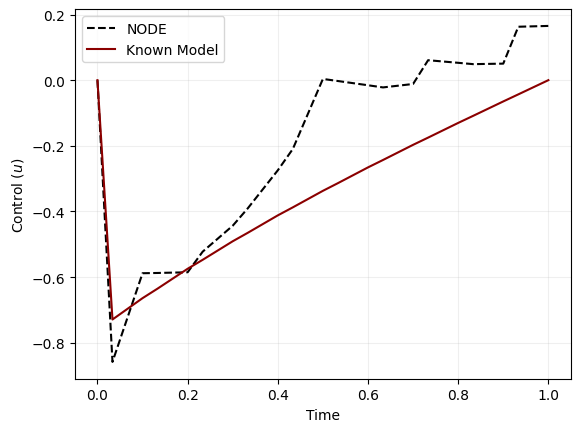

In [ ]:
OM_x1 = []
OM_x2 = []
OM_u = []
OM_t = []

print(sorted(OM.t))

for i in sorted(OM.t):
    OM_t.append(i)
    OM_x1.append(value(OM.x1[i]))
    OM_x2.append(value(OM.x2[i]))
    OM_u.append(value(OM.u[i]))

plt.plot(OM_t, OM_x1,'--',color='black',label='NODE $z_1$')
plt.plot(OM_t, OM_x2,'o:k',label='NODE $z_2$')
plt.plot(tt, x1,'--',color='darkred',label='Known Model $z_1$')
plt.plot(tt, x2,'o:',color='darkred',label='Known Model $z_2$')
plt.xlabel('Time')
plt.ylabel('State ($z$)')
plt.legend()
plt.grid(True,alpha=0.2)
plt.savefig('CS1_States_ReLU_50_LHS.png', dpi=300)
plt.show()

plt.plot(OM_t, OM_u,'--',color='black',label='NODE')
plt.plot(tt, u,'darkred',label='Known Model')
plt.xlabel('Time')
plt.ylabel('Control ($u$)')
plt.legend()
plt.grid(True,alpha=0.2)
plt.savefig('CS1_Control_ReLU_50_LHS.png', dpi=300)
plt.show()

LHS Sample

In [ ]:
!pip install pyDOE

  Preparing metadata (setup.py) ... done
  Created wheel for pyDOE: filename=pyDOE-0.3.8-py3-none-any.whl size=18168 sha256=15cd5717202b1e6d6c07144c4737e251f0a50afb2cedcf3c2ed847a3edc30458
  Stored in directory: /root/.cache/pip/wheels/ce/b6/d7/c6b64746dba6433c593e471e0ac3acf4f36040456d1d160d17
Successfully built pyDOE


In [ ]:
from pyDOE import lhs

# Define the number of samples and dimensions
num_samples = 63
num_dimensions = 3
# X V P S U
# Define the upper and lower bounds for each variable
bounds = np.array([[-3, 1], [-1, 1], [-1, 1]])

# Generate Latin Hypercube Samples
lhs_samples = lhs(num_dimensions, samples=num_samples, criterion='center')

# Rescale the samples to the specified bounds
scaled_samples = bounds[:, 0] + lhs_samples * (bounds[:, 1] - bounds[:, 0])


In [ ]:
def model_sample(y, t):
    X1=y[:,1]
    X2=y[:,2]
    U=y[:,0]

    dX1dt = U
    dX2dt = X1**2+U**2
    return np.column_stack((dX1dt,dX2dt))

In [ ]:
y_samp=model_sample(scaled_samples,1)

In [ ]:
y_samp.shape

(63, 2)

In [ ]:
scaled_samples.shape

(32, 3)

In [ ]:
# Function to subsample and save to CSV
def subsample_and_save(X, y, num_samples, base_filename):
    # Randomly select num_samples indices
    indices = np.random.choice(len(X), num_samples, replace=False)

    # Subsample the arrays
    X_subsample = X[indices]
    y_subsample = y[indices]

    # Convert to DataFrame
    X_df = pd.DataFrame(X_subsample, columns=[f'Feature_{i+1}' for i in range(X.shape[1])])
    y_df = pd.DataFrame(y_subsample, columns=[f'Target_{i+1}' for i in range(y.shape[1])])

    # Save to CSV
    X_filename = f"{base_filename}_X_{num_samples}.csv"
    y_filename = f"{base_filename}_y_{num_samples}.csv"
    X_df.to_csv(X_filename, index=False)
    y_df.to_csv(y_filename, index=False)
    print(f"Saved {num_samples} samples to {X_filename} and {y_filename}")

# Base filename for saving
base_filename = "CS1"

# Subsample and save for different sizes
for num_samples in [10000, 1000, 100, 10]:
    subsample_and_save(scaled_samples, y_samp, num_samples, base_filename)

Saved 10000 samples to CS1_X_10000.csv and CS1_y_10000.csv
Saved 1000 samples to CS1_X_1000.csv and CS1_y_1000.csv
Saved 100 samples to CS1_X_100.csv and CS1_y_100.csv
Saved 10 samples to CS1_X_10.csv and CS1_y_10.csv


In [ ]:
from sklearn.model_selection import train_test_split


X_train, X_val, Y_train, Y_val = train_test_split(scaled_samples, y_samp, test_size=0.2, random_state=42)
model_tf=k.Sequential()
model_tf.add(k.layers.Dense(50,activation='relu', input_shape=(3,)))
#model.add(k.layers.Dense(50,activation='relu'))
model_tf.add(k.layers.Dense(2))

model_tf.compile(optimizer='adam', loss='mean_squared_error')  # Compile the model

# Train the model
history = model_tf.fit(X_train, Y_train, epochs=3000, validation_data=(X_val, Y_val))

Streaming output truncated to the last 5000 lines.
2/2 [==============================] - 0s 67ms/step - loss: 0.0449 - val_loss: 0.1795
Epoch 502/3000
2/2 [==============================] - 0s 62ms/step - loss: 0.0447 - val_loss: 0.1791
Epoch 503/3000
2/2 [==============================] - 0s 59ms/step - loss: 0.0447 - val_loss: 0.1789
Epoch 504/3000
2/2 [==============================] - 0s 67ms/step - loss: 0.0444 - val_loss: 0.1784
Epoch 505/3000
2/2 [==============================] - 0s 62ms/step - loss: 0.0443 - val_loss: 0.1781
Epoch 506/3000
2/2 [==============================] - 0s 73ms/step - loss: 0.0440 - val_loss: 0.1778
Epoch 507/3000
2/2 [==============================] - 0s 54ms/step - loss: 0.0439 - val_loss: 0.1773
Epoch 508/3000
2/2 [==============================] - 0s 77ms/step - loss: 0.0437 - val_loss: 0.1769
Epoch 509/3000
2/2 [==============================] - 0s 56ms/step - loss: 0.0435 - val_loss: 0.1765
Epoch 510/3000
2/2 [==============================] - 0

In [ ]:
history = model_tf.fit(X_train, Y_train, epochs=500,  validation_data=(X_val, Y_val))

Epoch 1/500
2/2 [==============================] - 0s 331ms/step - loss: 4.9638e-04 - val_loss: 0.0167
Epoch 2/500
2/2 [==============================] - 0s 119ms/step - loss: 4.8158e-04 - val_loss: 0.0170
Epoch 3/500
2/2 [==============================] - 0s 149ms/step - loss: 4.8002e-04 - val_loss: 0.0172
Epoch 4/500
2/2 [==============================] - 0s 67ms/step - loss: 4.6914e-04 - val_loss: 0.0174
Epoch 5/500
2/2 [==============================] - 0s 45ms/step - loss: 4.7099e-04 - val_loss: 0.0174
Epoch 6/500
2/2 [==============================] - 0s 93ms/step - loss: 4.7939e-04 - val_loss: 0.0173
Epoch 7/500
2/2 [==============================] - 0s 90ms/step - loss: 4.7382e-04 - val_loss: 0.0171
Epoch 8/500
2/2 [==============================] - 0s 124ms/step - loss: 4.7311e-04 - val_loss: 0.0171
Epoch 9/500
2/2 [==============================] - 0s 85ms/step - loss: 4.6560e-04 - val_loss: 0.0173
Epoch 10/500
2/2 [==============================] - 0s 73ms/step - loss: 4.718

In [ ]:
model_tf.save('CS1_ReLU_50_LHS.h5')

Gaussian Process Samples

In [ ]:
df_t=pd.read_csv('t.csv')
df_u=pd.read_csv('u.csv')
df_x1=pd.read_csv('X1.csv')
df_x2=pd.read_csv('X2.csv')
u_full=df_u.to_numpy()[:,1:].reshape(-1)[0:100][::5]
t_full=df_t.to_numpy()[:,1:].reshape(-1)[0:100][::5]
x1_full=df_x1.to_numpy()[:,1:].reshape(-1)[0:100][::5]
x2_full=df_x2.to_numpy()[:,1:].reshape(-1)[0:100][::5]

input_full= np.transpose(np.array([x1_full,x2_full,u_full]))
input_full_t= np.transpose(np.array([x1_full,x2_full,u_full,t_full]))
output_full= np.transpose(np.array([x1_full,x2_full,u_full]))
input_full=torch.tensor(input_full).reshape(20,1,3)
output_full=torch.tensor(output_full).reshape(20,1,3)
t_tens=torch.tensor(t_full).reshape(20)

In [ ]:
composite_t = []
composite_u = []
composite_x1 = []
composite_x2 = []
composite_dx1_dt = []
composite_dx2_dt = []
for sample in range(100):
  u_samp=df_u.to_numpy()[:,1:].reshape(-1)[sample*100:sample*100+100]
  t_samp=df_t.to_numpy()[:,1:].reshape(-1)[sample*100:sample*100+100]
  x1_samp=df_x1.to_numpy()[:,1:].reshape(-1)[sample*100:sample*100+100]
  x2_samp=df_x2.to_numpy()[:,1:].reshape(-1)[sample*100:sample*100+100]
  spl_x1 = BSpline(t_samp,x1_samp, 2)
  spl_x2 = BSpline(t_samp,x2_samp, 2)

  dx1dt_samp=spl_x1.derivative(nu=1)(t_samp)
  dx2dt_samp=spl_x2.derivative(nu=1)(t_samp)

  composite_t.append(t_samp)
  composite_u.append(u_samp)
  composite_x1.append(x1_samp)
  composite_x2.append(x2_samp)
  composite_dx1_dt.append(dx1dt_samp)
  composite_dx2_dt.append(dx2dt_samp)

In [ ]:
input_data = np.concatenate([np.concatenate(composite_u, axis=0).reshape(-1,1),np.concatenate(composite_x1, axis=0).reshape(-1,1)
                            ,np.concatenate(composite_x2, axis=0).reshape(-1,1)],axis=1)

output_data = np.concatenate([np.concatenate(composite_dx1_dt, axis=0).reshape(-1,1),np.concatenate(composite_dx2_dt, axis=0).reshape(-1,1)],axis=1)

In [ ]:
input_data = torch.tensor(input_data, dtype=torch.float32)
output_data = torch.tensor(output_data, dtype=torch.float32)

In [ ]:
output_data.shape

torch.Size([10000, 2])

In [ ]:
# Function to subsample and save to CSV
def subsample_and_save(X, y, num_samples, base_filename):
    # Randomly select num_samples indices
    indices = np.random.choice(len(X), num_samples, replace=False)

    # Subsample the arrays
    X_subsample = X[indices]
    y_subsample = y[indices]

    # Convert to DataFrame
    X_df = pd.DataFrame(X_subsample, columns=[f'Feature_{i+1}' for i in range(X.shape[1])])
    y_df = pd.DataFrame(y_subsample, columns=[f'Target_{i+1}' for i in range(y.shape[1])])

    # Save to CSV
    X_filename = f"{base_filename}_X_{num_samples}.csv"
    y_filename = f"{base_filename}_y_{num_samples}.csv"
    X_df.to_csv(X_filename, index=False)
    y_df.to_csv(y_filename, index=False)
    print(f"Saved {num_samples} samples to {X_filename} and {y_filename}")

# Base filename for saving
base_filename = "CS1_GP"

# Subsample and save for different sizes
for num_samples in [10000, 1000, 100, 10]:
    subsample_and_save(input_data, output_data, num_samples, base_filename)

Saved 10000 samples to CS1_GP_X_10000.csv and CS1_GP_y_10000.csv
Saved 1000 samples to CS1_GP_X_1000.csv and CS1_GP_y_1000.csv
Saved 100 samples to CS1_GP_X_100.csv and CS1_GP_y_100.csv
Saved 10 samples to CS1_GP_X_10.csv and CS1_GP_y_10.csv


In [ ]:
X_train, X_val, Y_train, Y_val = train_test_split(input_data.numpy(),output_data.numpy(), test_size=0.99, random_state=42)
model_tf=k.Sequential()
model_tf.add(k.layers.Dense(50,activation='tanh', input_shape=(3,)))
#model.add(k.layers.Dense(50,activation='relu'))
model_tf.add(k.layers.Dense(2))

model_tf.compile(optimizer='adam', loss='mean_squared_error')  # Compile the model

# Train the model
history = model_tf.fit(X_train, Y_train, epochs=2000, batch_size=10, validation_data=(X_val, Y_val))

Epoch 1/2000
10/10 [==============================] - 7s 627ms/step - loss: 0.2919 - val_loss: 0.1837
Epoch 2/2000
10/10 [==============================] - 1s 133ms/step - loss: 0.1228 - val_loss: 0.0776
Epoch 3/2000
10/10 [==============================] - 1s 134ms/step - loss: 0.0601 - val_loss: 0.0467
Epoch 4/2000
10/10 [==============================] - 1s 132ms/step - loss: 0.0533 - val_loss: 0.0416
Epoch 5/2000
10/10 [==============================] - 1s 133ms/step - loss: 0.0506 - val_loss: 0.0364
Epoch 6/2000
10/10 [==============================] - 1s 134ms/step - loss: 0.0446 - val_loss: 0.0315
Epoch 7/2000
10/10 [==============================] - 3s 287ms/step - loss: 0.0408 - val_loss: 0.0292
Epoch 8/2000
10/10 [==============================] - 3s 290ms/step - loss: 0.0388 - val_loss: 0.0273
Epoch 9/2000
10/10 [==============================] - 1s 133ms/step - loss: 0.0370 - val_loss: 0.0252
Epoch 10/2000
10/10 [==============================] - 1s 132ms/step - loss: 0.035

KeyboardInterrupt: 

In [ ]:
model_tf

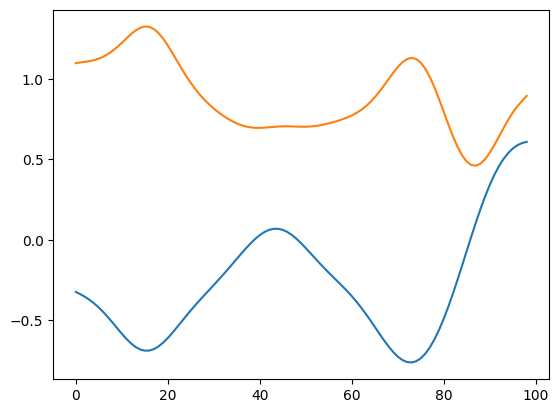

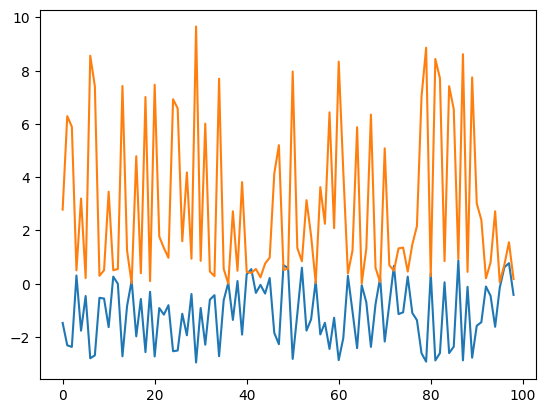

In [ ]:

plt.plot(input_data.numpy()[0:99,0])
plt.plot(output_data.numpy()[0:99,1])
plt.show()

plt.plot(scaled_samples[0:99,0])
plt.plot(y_samp[0:99,1])
plt.show()






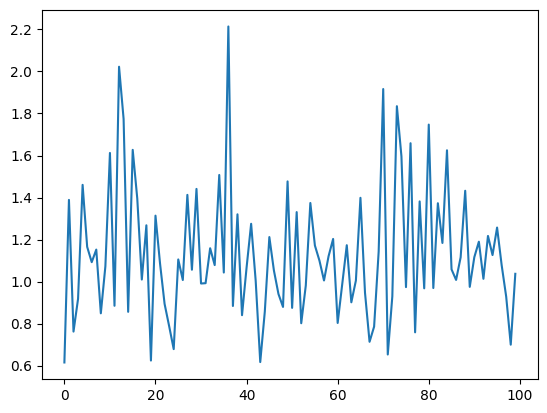

In [ ]:
plt.plot(Y_train[:,1])